# Figure 3 - Summary of Papers

Running the following cells creates the stylized table in Fig. 3. The final figure in the paper was augmented to include more descriptive labels and notes via PowerPoint. 

In [2]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import pandas as pd 

In [3]:
# Constants to help with sizing of figure
size = 1.5
scale_factor = 2

# Color scheme of figure. 
color_map = {
    'Data Avail': "#b0e6a0",
    'Open Source Code': "#b0e6a0",
    'Open Weight Model': "#b0e6a0",
    '2 to 5': '#136da5', 
    '6 to 9': '#136da5',
    '10+': '#136da5',
    'B': '#b0c4dd',
    'D': '#b0c4dd',
    'L': '#b0c4dd',
    'ND': '#b0c4dd',
    'R': '#b0c4dd',
    'CV': '#09487b',
    'LOSO': '#09487b',
    'SS': '#09487b',
    'A': '#87a6c8',
    'A+F1': '#87a6c8',
    'F1': '#87a6c8',
    'O': '#87a6c8',
    'Mult. Algs': '#0f5a90',
    'CW': '#0f5a90',
    'Dif Dataset': '#0f5a90',
    'Cross Dataset': '#0f5a90',
    'Replicable': '#dd7c4e', 
    'Reproducible': '#dd7c4e',
    'Space1': 'w',
    'Space2': 'w',
    'Space3': 'w',
    'Space4': 'w',
    'Space5': 'w',
    'Space6': 'w',
}

In [5]:
# Get data. NOTE: blank rows have been added to this csv to improve spacing in the final figure. 
data = pd.read_csv("./fig_data/fig_3/summary_of_papers.csv")

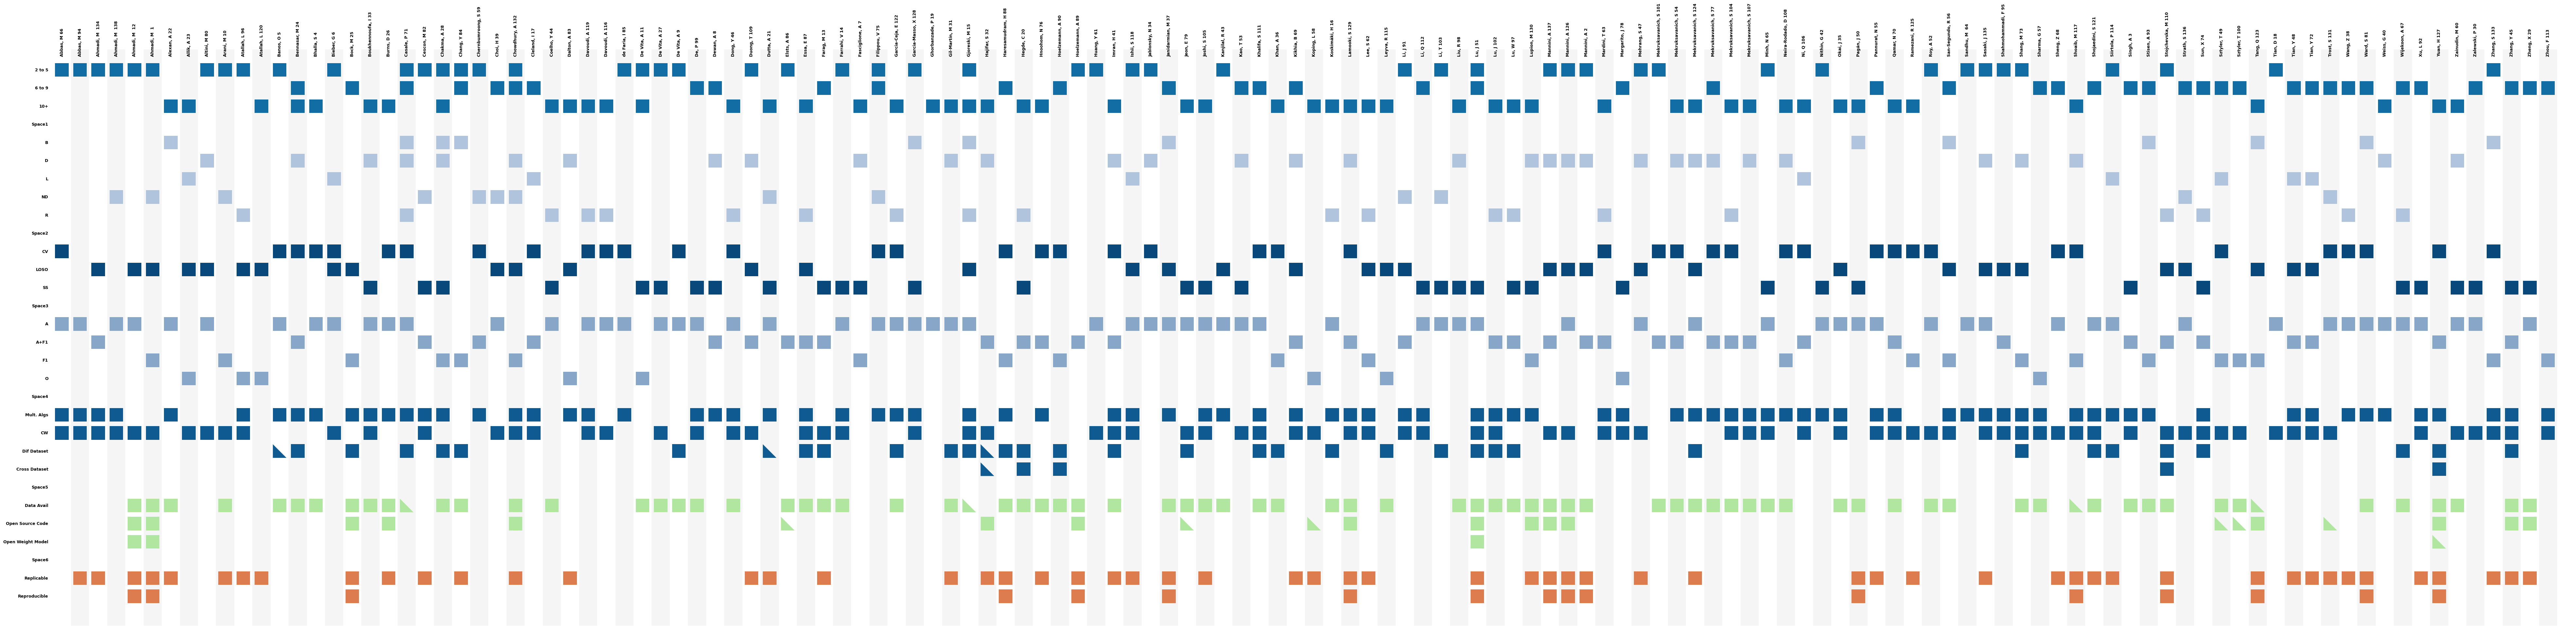

In [8]:
# Create figure
fig, ax = plt.subplots(figsize=(100, 100))

rows = list(data.columns)
n_rows = len(rows)
rows.remove('Article_ID')
rows.remove('Author (Last)')

n_cols = data.shape[0] 
cols = list(data["Article_ID"])

# Shade every other column for improved readability by article. 
for col_idx in range(n_cols):
    if col_idx % 2 == 1: 
        gray_rect = patches.Rectangle(
            (col_idx * scale_factor - scale_factor/8, -60),
            size+scale_factor/4, 
            n_rows + size + 60, 
            facecolor='gray', 
            alpha=0.075, 
            zorder=0 
        )
        ax.add_patch(gray_rect)

# Draw symbols for each non-empty values.
for row_idx, row_label in enumerate(rows):
    for col_idx in range(n_cols):
        color = color_map[row_label]
        value = data.at[col_idx, row_label]
        if str(value) != "nan":  
            if '*' in value: 
                square = patches.Polygon(
                    [[col_idx*(scale_factor), n_rows - row_idx*(scale_factor) - size],
                        [col_idx*(scale_factor) + size,n_rows - row_idx*(scale_factor) - size],
                        [col_idx*(scale_factor),n_rows - row_idx*(scale_factor)]], 
                     facecolor=color, 
                     alpha=1,)
            elif color == 'w':
                pass
            else:
                square = patches.Rectangle(
                    (col_idx*(scale_factor), n_rows - row_idx*(scale_factor) - size), 
                    size, 
                    size,  
                    facecolor=color, alpha=1,)
            
            ax.add_patch(square)

# Add row labels.
for row_idx, row_label in enumerate(rows):
    ax.text(-size/2, n_rows - row_idx*scale_factor - size/2, row_label,
           ha='right', va='center', fontsize=9, fontweight='bold')
    
# Add article identification to the columns.
for col_id in range(n_cols):
    col = cols[col_id]
    name = list(data["Author (Last)"])[col_id]
    ax.text(col_id*scale_factor + size/2, n_rows + size/2, f"{name} {col}",
           ha='center', va='bottom', fontsize=9, fontweight='bold', rotation=90)
    
ax.set_xlim(-2, n_cols*(1.25)+105)
ax.set_ylim(-30, n_rows + size)
ax.set_aspect('equal')
ax.axis('off')

plt.savefig('./output_figs/Fig_3_Summary_of_Papers.png', dpi=300, bbox_inches='tight')

plt.show()

# Figure 4 - Missing Attributes

Running the following cells creates the bar plot shown in Fig. 4. The final figure in the paper was augmented to include more descriptive labels and notes via PowerPoint. 


In [9]:
import matplotlib.pyplot as plt

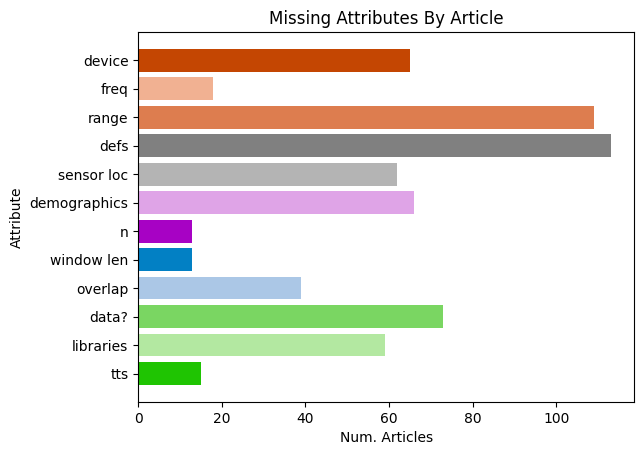

In [10]:
fig, ax = plt.subplots()

attributes = ['device', 'freq', 'range',  'defs', 'sensor loc', 'demographics', 'n', 'window len', 'overlap', 'data?', 'libraries', 'tts']
num_articles = [65, 18, 109, 113, 62, 66, 13, 13, 39, 73, 59, 15]
bar_colors = ['#C44602', '#f1b192', '#dd7d4f', '#808080', '#b4b4b4', '#dfa4e7',  '#A702C4', '#0280C4',  '#abc7e6', '#7ad662', '#b3e8a1', '#1FC402']

ax.barh(attributes, num_articles, label=attributes, color=bar_colors)

ax.invert_yaxis()

ax.set_ylabel('Attribute')
ax.set_xlabel('Num. Articles')
ax.set_title('Missing Attributes By Article')

plt.savefig("./output_figs/Fig_4_Missing_Attributes.png", dpi=300)

plt.show()

# Fig 5 - Independent Inference using Open-weight Models (trained on ASTRI dataset)

Running the following cells creates the stylized timeline of inferences versus ground truth in Fig. 5. The final figure in the paper was augmented to include more descriptive labels and notes via PowerPoint. 

**NOTE**: This code requires that inference has already been completed. We supply the results of our raw predictions in `./`. To recreate this inference, see `/sec_6_inference/README.md`.

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [14]:
# Map from PAAWS Taxonomy to ASTRI activities.
astri_mapping = {
    'Standing_Still': 'Standing',
    'Stand_Conversation_Lab': 'Standing',
    'Standing_With_Movement': 'Standing',

    'Sitting_Still': 'Sitting',
    'Sit_Typing_Lab': 'Sitting',
    'Sit_Recline_Web_Browse_Lab': 'Sitting',
    'Sit_Writing_Lab': 'Sitting',
    'Sit_Recline_Talk_Lab': 'Sitting',
    'Sitting_With_Movement': 'Sitting',

    'Lying_Still': 'Lying',
    'Lying_On_Left_Side_Lab': 'Lying',
    'Lying_On_Right_Side_Lab': 'Lying',
    'Lying_On_Back_Lab': 'Lying',
    'Lying_On_Stomach_Lab': 'Lying',
    'Lying_With_Movement': 'Lying',

    'Walking': 'Walking',
    'Walking_Slow': 'Walking',
    'Walking_Fast': 'Walking',
    'Walking_Up_Stairs': 'Walking',
    'Walking_Down_Stairs': 'Walking',
    'Walking_Treadmill': 'Walking',
    'Treadmill_2mph_Lab': 'Walking',
    'Treadmill_3mph_Conversation_Lab': 'Walking',
    'Treadmill_3mph_Drink_Lab': 'Walking',
    'Treadmill_3mph_Free_Walk_Lab': 'Walking',
    'Treadmill_3mph_Briefcase_Lab': 'Walking',
    'Treadmill_3mph_Hands_Pockets_Lab': 'Walking',
    'Treadmill_4mph_Lab': 'Walking',

    'Stationary_Biking_300_Lab': 'Other',
    'Exercising_Gym_Stationary_Bike': 'Other',
    'Cycling_Active_Pedaling_Stationary_Bike': 'Other',
    'Cycling_Active_Pedaling_Regular_Bicycle': 'Other',

    'In_Transit_Driving_Car': 'Other',

    'In_Transit_Passive_Train/Bus/Plane': 'Other',
    'In_Transit_Passive_Car': 'Other',

    'Running_Non-Treadmill': 'Other',
    'Running_Treadmill': 'Other',
    
    'Playing_Frisbee': 'Other',
    'Playing_Exergame': 'Other',
    'Playing_Sports/Games': 'Other',
    'Doing_Resistance_Training_Free_Weights': 'Other',
    'Exercising_Gym_Other': 'Other',
    'Doing_Resistance_Training_Other': 'Other',
    'Exercising_Gym_Treadmill': 'Other',
    'Arm_Curls_Lab': 'Other',
    'Doing_Martial_Arts': 'Other',
    'Push_Up_Modified_Lab': 'Other',
    'Doing_Resistance_Training': 'Other',
    'Push_Up_Lab': 'Other',
    'Ab_Crunches_Lab': 'Other',
    'Machine_Leg_Press_Lab': 'Other',
    'Machine_Chest_Press_Lab': 'Other',
    'Running_Non_Treadmill': 'Other',
    'Running_Treadmill': 'Other',

    'Dry_Mopping': 'Other',
    'Cleaning': 'Other',
    'Dusting': 'Other',
    'Doing_Common_Housework_Light': 'Other',
    'Folding_Clothes': 'Other',
    'Doing_Common_Housework': 'Other',
    'Ironing': 'Other',
    'Doing_Dishes': 'Other',
    'Loading/Unloading_Washing_Machine/Dryer': 'Other',
    'Doing_Home_Repair_Light': 'Other',
    'Organizing_Shelf/Cabinet': 'Other',
    'Doing_Home_Repair': 'Other',
    'Putting_Clothes_Away': 'Other',
    'Packing/Unpacking_Something': 'Other',
    'Sweeping': 'Other',
    'Vacuuming': 'Other',
    'Stand_Shelf_Load_Lab': 'Other',
    'Stand_Shelf_Unload_Lab': 'Other',
    'Washing_Dishes_Lab': 'Other', 
    'Watering_Plants': 'Other', 

    'Chopping_Food_Lab': 'Cooking',
    'Cooking/Prepping_Food': 'Cooking',

    'Eating/Dining': 'Eating/Drinking',

    'Washing_Hands': 'Other',
    'Brushing_Teeth': 'Other',
    'Brushing/Combing/Tying_Hair': 'Other',
    'Washing_Face': 'Other',
    'Applying_Makeup': 'Other',
    'Flossing_Teeth': 'Other', 
    'Blowdrying_Hair': 'Other',

    'Kneeling_With_Movement': 'Other',
    'Kneeling_Still': 'Other',

    "Puttering_Around": "Other",
    
    "Before_Data_Collection": "Before_Data_Collection", 
    "After_Data_Collection": "After_Data_Collection", 
}

# Map of model predicitons to activity names. 
astri_pred_map = {
    0: "Walking", 
    1: "Sitting", 
    2: "Standing", 
    3: "Squatting", 
    4: "Lying"
}

In [15]:
# Get raw data and map to the lables the model can predict
astri_data = pd.read_csv("./fig_data/fig_5/DS_10_Labels.csv", parse_dates=["Time"])
astri_data.set_index("Time", inplace=True)
astri_data["Mapped"] = astri_data["Raw_Label"].map(astri_mapping)

# Get right/left wrist predictions. 
rw_preds = pd.read_csv("./fig_data/fig_5/PREDICTIONS_ASTRI_RightWrist.csv")
astri_data["Pred_RW"] = list(rw_preds["PREDS"])
lw_preds = pd.read_csv("./fig_data/fig_5/PREDICTIONS_ASTRI_LeftWrist.csv")
astri_data["Pred_LW"] = list(lw_preds["PREDS"])

# Map predictions from integers to activity names. 
astri_data["Pred_RW_Map"] = astri_data["Pred_RW"].map(astri_pred_map)
astri_data["Pred_LW_Map"] = astri_data["Pred_LW"].map(astri_pred_map)

# Set up timestamps for easy computation of bar width. 
astri_data = astri_data.drop(astri_data[astri_data["Mapped"] == "Before_Data_Collection"].index)
astri_data["Stop_Time"] = astri_data.index + pd.Timedelta(seconds=6.15)
astri_data.index = astri_data.index.round('s')
astri_data['Stop_Time'] = astri_data['Stop_Time'].dt.round('s')
astri_data["Start_Time"] = astri_data.index 

# Remove values not on Nov. 2 and values where we do not have ground truth. 
astri_data_dropped = astri_data.drop(
    astri_data[astri_data.index < pd.to_datetime("2021-11-02 04:00:00")].index)
data = astri_data_dropped.dropna()


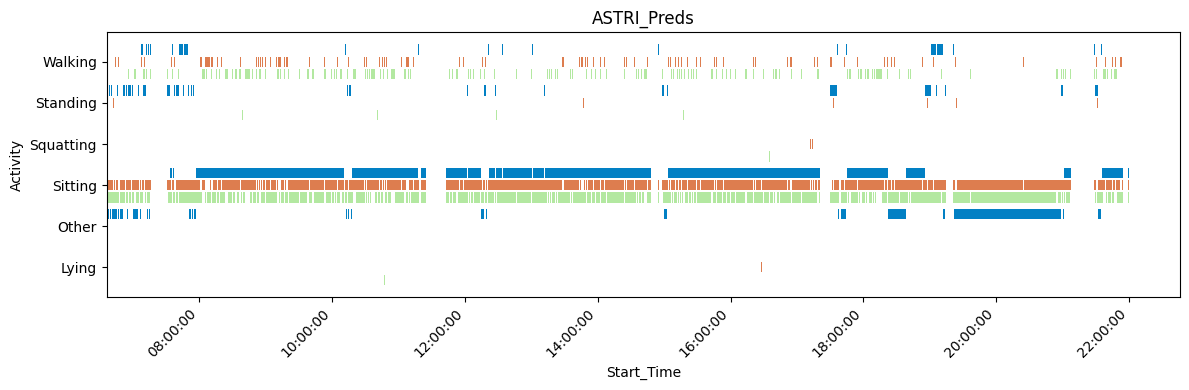

In [16]:
# Helper maps and lists. 
activities = sorted(['Lying', 'Other', 'Sitting', 'Squatting', 'Standing', 'Walking'])
activity_to_y = {act: i for i, act in enumerate(activities)}

# Plot the data and predicitions. 
fig, ax = plt.subplots(figsize=(12, 4))
activity_to_y = {act: i for i, act in enumerate(activities)}

for idx, row in data.iterrows():
        y_val_gt = activity_to_y[row["Mapped"]]
        y_val_rw = activity_to_y[row["Pred_RW_Map"]]
        y_val_lw = activity_to_y[row["Pred_LW_Map"]]
        
        # Plot ground truth (GT).
        ax.barh(y_val_gt+.3,
                width=row['Stop_Time'] - row['Start_Time'],
                left=row['Start_Time'], 
                height=0.25,
                align='center',
                color ='#0280C4',
                )

        # Plot the right wrist (RW) prediction.
        ax.barh(y_val_rw, 
                width=row['Stop_Time'] - row['Start_Time'],
                left=row['Start_Time'], 
                height=0.25,
                align='center',
                color ='#dd7d4f',
                )

        # Plot the left wrist (LW) prediction.
        ax.barh(y_val_lw-.3, 
                width=row['Stop_Time'] - row['Start_Time'],
                left=row['Start_Time'], 
                height=0.25,
                align='center',
                color ='#b3e8a1',)

ax.set_yticks(range(len(activities)))
ax.set_yticklabels(activities)
ax.set_xlabel('Start_Time')
ax.set_ylabel('Activity')
ax.set_title("ASTRI_Preds")

# Add x-axis dates/times nicely.
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.savefig('./output_figs/Fig_5_ASTRI_Preds.png', dpi=300, bbox_inches='tight')
plt.show()

# Fig 6 - Independent Inference using Open-weight Models (trained on ADL dataset)

Running the following cells creates the stylized timeline of inferences versus ground truth in Fig. 6. The final figure in the paper was augmented to include more descriptive labels and notes via PowerPoint. 

**NOTE**: This code requires that inference has already been completed. We supply the results of our raw predictions in `./`. To recreate this inference, see `/sec_6_inference/README.md`.

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [18]:
# Map from PAAWS Taxonomy to ADL activities.
adl_mapping = {
    'Standing_Still': 'Stand-Up',
    'Stand_Conversation_Lab': 'Stand-Up',
    'Standing_With_Movement': 'Stand-Up',

    'Sitting_Still': 'Sit Down',
    'Sit_Typing_Lab': 'Sit Down',
    'Sit_Recline_Web_Browse_Lab': 'Sit Down',
    'Sit_Writing_Lab': 'Sit Down',
    'Sit_Recline_Talk_Lab': 'Sit Down',
    'Sitting_With_Movement': 'Sit Down',

    'Lying_Still': 'Other',
    'Lying_On_Left_Side_Lab': 'Other',
    'Lying_On_Right_Side_Lab': 'Other',
    'Lying_On_Back_Lab': 'Other',
    'Lying_On_Stomach_Lab': 'Other',
    'Lying_With_Movement': 'Other',

    'Walking_Up_Stairs': 'Climb Stairs',
    'Walking_Down_Stairs': 'Climb Stairs',

    'Walking': 'Walk',
    'Walking_Slow': 'Walk',
    'Walking_Fast': 'Walk',
    'Walking_Treadmill': 'Walk',
    'Treadmill_2mph_Lab': 'Walk',
    'Treadmill_3mph_Conversation_Lab': 'Walk',
    'Treadmill_3mph_Drink_Lab': 'Walk',
    'Treadmill_3mph_Free_Walk_Lab': 'Walk',
    'Treadmill_3mph_Briefcase_Lab': 'Walk',
    'Treadmill_3mph_Hands_Pockets_Lab': 'Walk',
    'Treadmill_4mph_Lab': 'Walk',

    'Stationary_Other_300_Lab': 'Other',
    'Exercising_Gym_Stationary_Bike': 'Other',
    'Cycling_Active_Pedaling_Stationary_Bike': 'Other',
    'Cycling_Active_Pedaling_Regular_Bicycle': 'Other',

    'Running_Non-Treadmill': 'Other',
    'Running_Treadmill': 'Other',
    
    'Playing_Frisbee': 'Other',
    'Playing_Exergame': 'Other',
    'Playing_Sports/Games': 'Other',
    'Doing_Resistance_Training_Free_Weights': 'Other',
    'Exercising_Gym_Other': 'Other',
    'Doing_Resistance_Training_Other': 'Other',
    'Exercising_Gym_Treadmill': 'Other',
    'Arm_Curls_Lab': 'Other',
    'Doing_Martial_Arts': 'Other',
    'Push_Up_Modified_Lab': 'Other',
    'Doing_Resistance_Training': 'Other',
    'Push_Up_Lab': 'Other',
    'Ab_Crunches_Lab': 'Other',
    'Machine_Leg_Press_Lab': 'Other',
    'Machine_Chest_Press_Lab': 'Other',
    'Running_Non_Treadmill': 'Other',
    'Running_Treadmill': 'Other',

    'Dry_Mopping': 'Other',
    'Cleaning': 'Other',
    'Dusting': 'Other',
    'Doing_Common_Housework_Light': 'Other',
    'Folding_Clothes': 'Other',
    'Doing_Common_Housework': 'Other',
    'Ironing': 'Other',
    'Doing_Dishes': 'Other',
    'Loading/Unloading_Washing_Machine/Dryer': 'Other',
    'Doing_Home_Repair_Light': 'Other',
    'Organizing_Shelf/Cabinet': 'Other',
    'Doing_Home_Repair': 'Other',
    'Putting_Clothes_Away': 'Other',
    'Packing/Unpacking_Something': 'Other',
    'Sweeping': 'Other',
    'Vacuuming': 'Other',
    'Stand_Shelf_Load_Lab': 'Other',
    'Stand_Shelf_Unload_Lab': 'Other',
    'Washing_Dishes_Lab': 'Other', 
    'Watering_Plants': 'Other', 

    'Chopping_Food_Lab': 'Other',
    'Cooking/Prepping_Food': 'Other',

    'Eating/Dining': 'Eating/Drinking',

    'Washing_Hands': 'Other',
    'Brushing_Teeth': 'Other',
    'Brushing/Combing/Tying_Hair': 'Other',
    'Washing_Face': 'Other',
    'Applying_Makeup': 'Other',
    'Flossing_Teeth': 'Other', 
    'Blowdrying_Hair': 'Other',

    'Kneeling_With_Movement': 'Other',
    'Kneeling_Still': 'Other',

    "Puttering_Around": "Other",

    "Before_Data_Collection": "Before_Data_Collection", 
    "After_Data_Collection": "After_Data_Collection", 
}

In [19]:
# Get raw data and map to the lables the model can predict
adl_data = pd.read_csv("./fig_data/fig_6/DS_10_Labels.csv", parse_dates=["Time"])
adl_data.set_index("Time", inplace=True)
adl_data["Mapped"] = adl_data["Raw_Label"].map(adl_mapping)

# Get right wrist predictions. NOTE: there is no map from predictions to activity names for ADL
rw_preds = pd.read_csv("./fig_data/fig_6/PREDICTIONS_ADL_RightWrist.csv")
adl_data["Pred_RW"] = list(rw_preds["PREDS"])

# Set up timestamps for easy computation of bar width. 
adl_data = adl_data.drop(adl_data[adl_data["Mapped"] == "Before_Data_Collection"].index)
adl_data["Stop_Time"] = adl_data.index + pd.Timedelta(seconds=6.15)
adl_data.index = adl_data.index.round('s')
adl_data['Stop_Time'] = adl_data['Stop_Time'].dt.round('s')
adl_data["Start_Time"] = adl_data.index 

# Remove values not on Nov. 2 and values where we do not have ground truth. 
adl_data_dropped = adl_data.drop(
    adl_data[adl_data.index < pd.to_datetime("2021-11-02 04:00:00")].index)
data = adl_data_dropped.dropna()

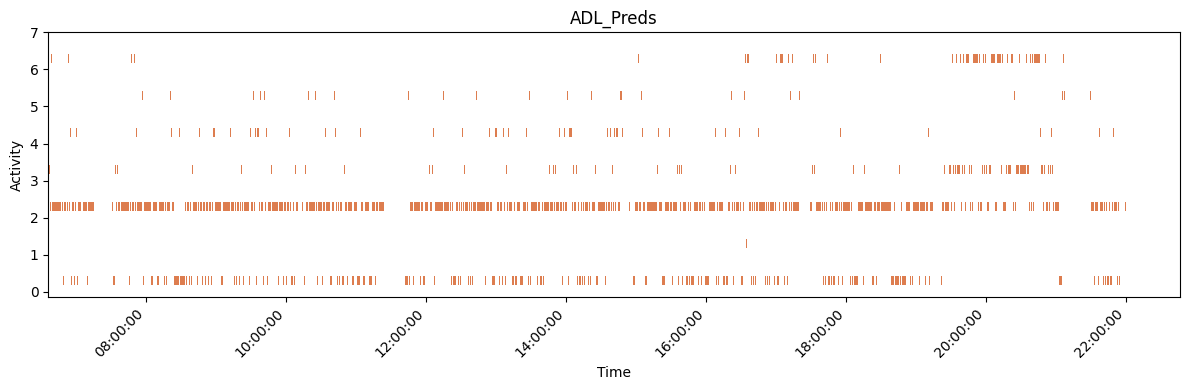

In [20]:
# Create ADL Pred figure. 
activities = sorted([0, 1, 2, 3, 4, 5, 6, 7])
activity_to_y = {act: i for i, act in enumerate(activities)}

fig, ax = plt.subplots(figsize=(12, 4))
activity_to_y = {act: i for i, act in enumerate(activities)}

# Plot each activity as a horizontal bar
for idx, row in data.iterrows():
        y_val = activity_to_y[row["Pred_RW"]]
        ax.barh(y_val+.3, 
                width=row['Stop_Time'] - row['Start_Time'],
                left=row['Start_Time'], 
                height=0.25,
                align='center',
                # GT: color ='#0280C4',
                # RW color:
                color ='#dd7d4f',)

# Format the plot
ax.set_yticks(range(len(activities)))
ax.set_yticklabels(activities)
ax.set_xlabel('Time')
ax.set_ylabel('Activity')
ax.set_title('ADL_Preds')

# Format x-axis to show dates/times nicely
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.savefig('./output_figs/Fig_6_ADL_Preds.png', dpi=300, bbox_inches='tight')
plt.show()

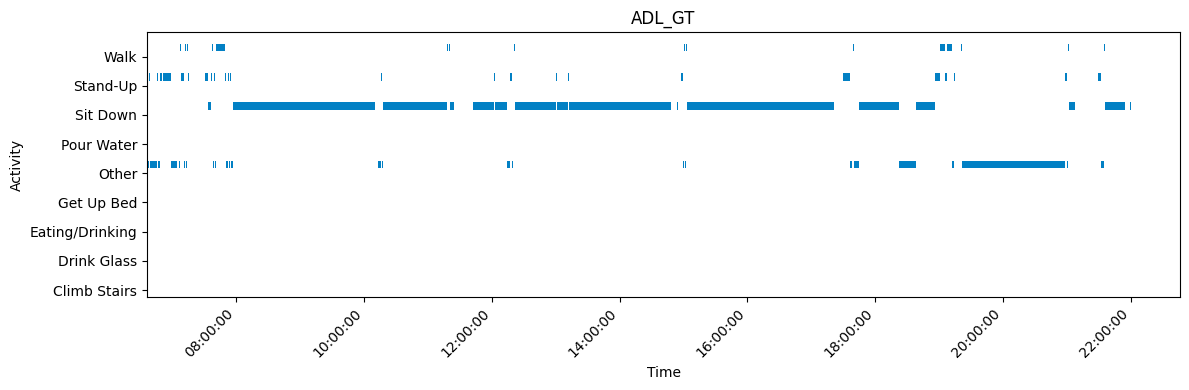

In [21]:
# Create ADL GT figure. 

activities = sorted(["Walk", "Stand-Up", "Sit Down", "Pour Water", "Other", "Get Up Bed", "Eating/Drinking", "Drink Glass", "Climb Stairs"])
activity_to_y = {act: i for i, act in enumerate(activities)}

fig, ax = plt.subplots(figsize=(12, 4))
activity_to_y = {act: i for i, act in enumerate(activities)}

# Plot each activity as a horizontal bar
for idx, row in data.iterrows():
        y_val = activity_to_y[row["Mapped"]]
        ax.barh(y_val+.3, 
                width=row['Stop_Time'] - row['Start_Time'],
                left=row['Start_Time'], 
                height=0.25,
                align='center',
                color ='#0280C4',)

# Format the plot
ax.set_yticks(range(len(activities)))
ax.set_yticklabels(activities)
ax.set_xlabel('Time')
ax.set_ylabel('Activity')
ax.set_title('ADL_GT')

# Format x-axis to show dates/times nicely
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.savefig('./output_figs/Fig_6_ADL_GT.png', dpi=300, bbox_inches='tight')
plt.show()